# Workflow
This notebook illustrates the **madis-data** workflow. It performs the following tasks:

* download MESONET surface observations data files for January 2026 from the [MADIS archive](https://madis-data.ncep.noaa.gov/madisPublic1/data/archive/),
* extract January 2026 data for stations in the state of Colorado of the following variables:
    - 2 m temperature,
    - 2 m dewpoint temperature,
    - 10 m west-east and south-north wind speed,
    - solar radiation,
* save the extracted data in a s netCDF file,
* interpolate the data to full-hourly time series,
* save the full-hourly time series in a netCDF file,
* plot the original and the full-hourly interpolated time series at an individual station over select time intervals,
* plot the stations in the state of Colorado on a US map.

Downloading the data files from the [MADIS archive](https://madis-data.ncep.noaa.gov/madisPublic1/data/archive/) takes approximately 1 hour and requires approximately 30 GB disk space. Once the data files have been downloaded, the rest of the script runs in under a few minutes on a machine with 8 cores. Progress is reported by the data download step and by each computationally expensive step.

This notebook requires the Jupyter kernel madis-data, which is automaticaly installed as part of the madis-data conda development environment. The  conda development environment can be installed from the root directory of the **madis-data** distribution with

    make setup-dev-env

In [1]:
# Automatically reload modules
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
from datetime import datetime, timedelta

import numpy as np
import xarray as xr
import pandas as pd
from matplotlib import pyplot as plt

import pandas as pd
import geopandas as gpd

import h5netcdf

In [3]:
from madis_data.mesonet import download_mesonet, plot_locations_conus, extract_station_data, interpolate_to_full_hour, merge_hourly
from madis_data.xarray_tools import get_missing_value, mask_with_missing_value
from madis_data.mesonet_region_filter import filter_by_region

## Helper functions

In [4]:
def elapsed_time(time_start: datetime | None = None) -> datetime:
    if time_start:
        print('Elapsed time: ' + str(datetime.now()-time_start))
    return datetime.now()

## Settings

In [5]:
start_date = datetime(2025,12,31,0,0,0)
end_date = datetime(2026,1,31,23,0,0)

In [6]:
data_dir = Path('../data')

In [7]:
file_tag = str(start_date).replace(' ','_') + '-' + str(end_date).replace(' ','_')

## Download and pre-process MADIS Mesonet data

For some dates and times, no data files are available on the server, and the following will issue corresponding warnings.

In [8]:
time_start = elapsed_time()

In [9]:
mm_files = download_mesonet(start_date, end_date, data_dir, n_jobs = 24, preprocess = True, refresh = False)

Progress: 100.00 %


In [10]:
time_start = elapsed_time(time_start)

Elapsed time: 0:00:04.555992


## Isolate data for stations in Colorado

In [11]:
time_start = elapsed_time()

In [12]:
region_name = 'CO'

In [13]:
ds_region = filter_by_region(mm_files, region_name, n_jobs= 24)

ERROR 1: PROJ: proj_create_from_database: Open of /home/jkazil/Software/miniforge3/envs/madis-data/share/proj failed
Scanning station metadata: 100%|██████████| 768/768 files [01:00<00:00, 12.63files/s]


The coordinates of the following stations change by more than the selected thresholds. This may represent an actual or a spurious change in station location. These stations are ignored. Coordinates are listed as (latitude, longitude, elevation):
SCHA2: [(59.69269943237305, -151.3939971923828, 115.8239974975586), (59.68000030517578, -151.3800048828125, 0.0)]
G2661: [(37.98017120361328, -122.5396728515625, 158.0), (37.980220794677734, -122.5396728515625, 57.0)]
MTCA2: [(65.4000015258789, -146.10000610351562, 916.1199951171875), (65.36000061035156, -146.08639526367188, 645.9000244140625)]
G6317: [(41.5128288269043, -120.3635025024414, 1654.0), (41.50825119018555, -120.3653335571289, 1811.0)]
MNDA2: [(58.42972183227539, 134.57278442382812, 435.0), (58.42972183227539, -134.57278442382812, 37.79999923706055)]
BRTA2: [(59.80167007446289, -150.88278198242188, 0.8999999761581421), (59.80167007446289, -150.88278198242188, 85.64700317382812)]
LCHN2: [(41.848331451416016, -119.63583374023438, 1985

Extracting regional records: 100%|██████████| 768/768 files [00:19<00:00, 38.87files/s]


In [14]:
time_start = elapsed_time(time_start)

Elapsed time: 0:01:21.139823


Save the data for the region as a netCDF file

In [15]:
region_out_file_name = region_name + '.' + file_tag  + '.nc'

In [16]:
region_out_file = data_dir / Path(region_out_file_name)

In [17]:
ds_region.to_netcdf(region_out_file)

## Plot stations in the region on a map

In [18]:
plot_file_name = region_name + '.' + file_tag  + '_stations.png'
plot_file = data_dir / plot_file_name

plot_file = plot_locations_conus(
    list(ds_region['stationID'].values),
    list(ds_region['latitude'].values),
    list(ds_region['longitude'].values),
    plot_file)

## Isolate time series for each station in the region

In [19]:
time_start = elapsed_time()

In [20]:
station_ids = list(ds_region['stationID'].values)

In [21]:
ds_station_dict = extract_station_data(ds_region,station_ids)

Extracting data by station ...
Completed loading data to memory - moving on to preparation of station identifiers ...
Completed preparation of station identifiers - moving on to selection of data at requested stations ...
Completed selection of data at requested stations - moving on to assembling valid data at requested stations ...
Completed assembling valid data at requested stations - moving on to building datasets for requested stations ...
Completed building datasets for requested stations


In [22]:
time_start = elapsed_time(time_start)

Elapsed time: 0:00:04.507240


## Interpolate to full-hourly time series for January 2025

In [23]:
time_start = elapsed_time()

In [24]:
start_date_hourly = datetime(2026,1,1,0,0,0)
end_date_hourly = datetime(2026,1,31,23,0,0)

In [25]:
ds_station_hourly_dict = interpolate_to_full_hour(ds_station_dict,start_date=start_date_hourly,end_date=end_date_hourly)

Progress: 100.00 %


In [26]:
ds_hourly = merge_hourly(ds_station_hourly_dict)

In [27]:
time_start = elapsed_time(time_start)

Elapsed time: 0:00:46.739958


Save the full-hourly interpolated data as a netCDF file

In [28]:
file_tag_hourly = str(start_date_hourly).replace(' ','_') + '-' + str(end_date_hourly).replace(' ','_') + '.hourly'

In [29]:
region_out_file_name_hourly = region_name + '.' + file_tag_hourly + '.nc'

In [30]:
ds_hourly.to_netcdf(data_dir / Path(region_out_file_name_hourly), engine='h5netcdf', mode='w')

Plot the original and the full-hourly interpolated data at the station

In [31]:
ds_hourly = xr.open_dataset(data_dir / Path(region_out_file_name_hourly))

## Plot the original time series and the full-hourly interpolated time series for a given station

Select a station

In [32]:
station_id = 'AR893'

Find the array index of the station in the full-hourly interpolated dataset

In [33]:
station_ix = np.flatnonzero(ds_hourly['station'].values == station_id)

Time range to plot

In [34]:
time_min = max(ds_station_dict[station_id]['time'][0],ds_hourly['time'][0])
time_max = min(ds_station_dict[station_id]['time'][-1],ds_hourly['time'][-1])

Time zone

In [35]:
units = ds_hourly['time'].encoding['units']
reference_time = pd.Timestamp(units.split(' since ', 1)[1])
timezone = str(reference_time.tz)

Plot title

In [36]:
title = 'Station ' + station_id + ', ' + ds_hourly['STATION_NAME'][station_ix].values[0] + ', ' \
       + str(ds_hourly['LAT'][station_ix].values[0]) + ds_hourly['LAT'].attrs['units'] + ', ' \
       + str(ds_hourly['LON'][station_ix].values[0]) + ds_hourly['LON'].attrs['units'] + ', ' \
       + str(ds_hourly['ELEV'][station_ix].values[0]) + ' ' + ds_hourly['ELEV'].attrs['units']

Do your worst

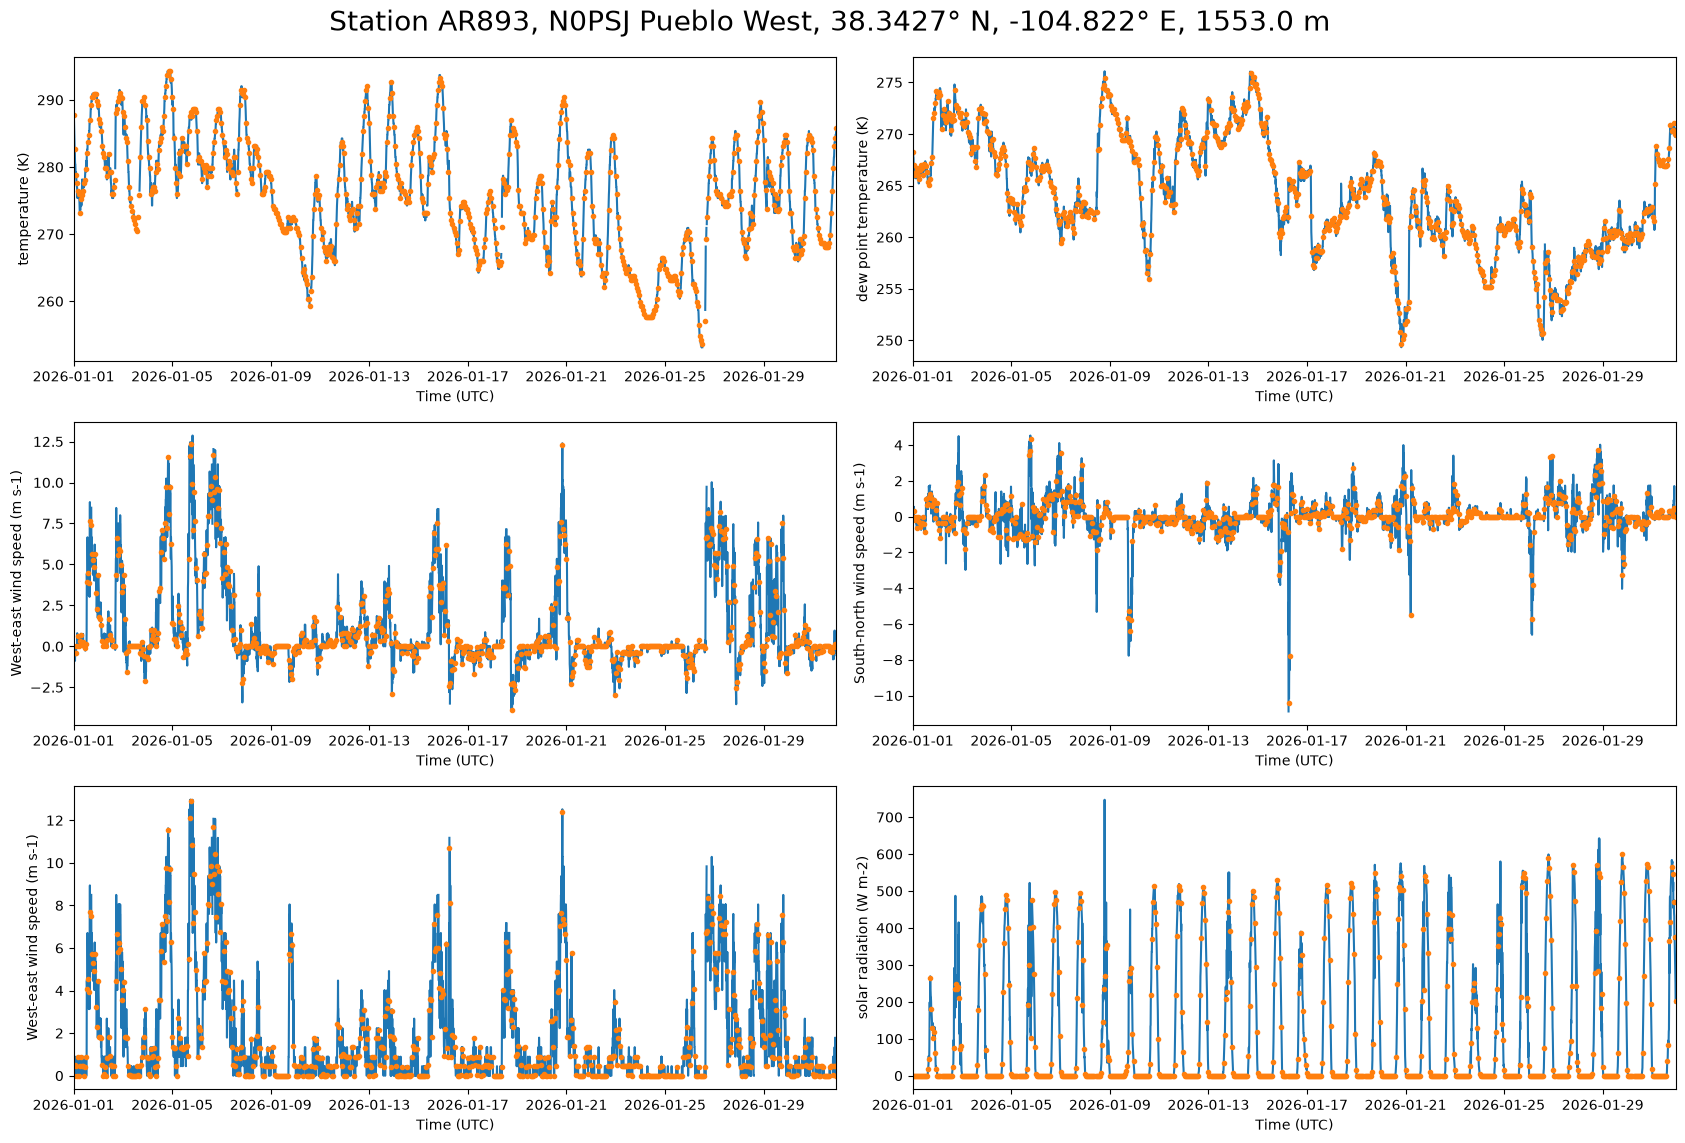

In [37]:
fig, axes = plt.subplots(3,2,figsize=(18,12),squeeze=False)

fig.suptitle(title, fontsize=20, y=0.98,)

fig.subplots_adjust(left=0.08,right=0.97,bottom=0.08,top=0.94,wspace=0.10,hspace=0.20)

var_name = 'temperature'
axes[0,0].plot(ds_station_dict[station_id]['time'],ds_station_dict[station_id][var_name][:].values)
axes[0,0].plot(ds_hourly['time'],ds_hourly[var_name][:,station_ix].values,marker='.',linewidth=0)
axes[0,0].set_ylabel(ds_hourly[var_name].attrs['long_name'] + ' (' + ds_hourly[var_name].attrs['units'] + ')')

var_name = 'dewpoint'
axes[0,1].plot(ds_station_dict[station_id]['time'],ds_station_dict[station_id][var_name][:].values)
axes[0,1].plot(ds_hourly['time'],ds_hourly[var_name][:,station_ix].values,marker='.',linewidth=0)
axes[0,1].set_ylabel(ds_hourly[var_name].attrs['long_name'] + ' (' + ds_hourly[var_name].attrs['units'] + ')')

var_name = 'U10'
axes[1,0].plot(ds_station_dict[station_id]['time'],ds_station_dict[station_id][var_name][:].values)
axes[1,0].plot(ds_hourly['time'],ds_hourly[var_name][:,station_ix].values,marker='.',linewidth=0)
axes[1,0].set_ylabel(ds_hourly[var_name].attrs['long_name'] + ' (' + ds_hourly[var_name].attrs['units'] + ')')

var_name = 'V10'
axes[1,1].plot(ds_station_dict[station_id]['time'],ds_station_dict[station_id][var_name][:].values)
axes[1,1].plot(ds_hourly['time'],ds_hourly[var_name][:,station_ix].values,marker='.',linewidth=0)
axes[1,1].set_ylabel(ds_hourly[var_name].attrs['long_name'] + ' (' + ds_hourly[var_name].attrs['units'] + ')')

var_name = 'Wind speed'
axes[2,0].plot(ds_station_dict[station_id]['time'],np.sqrt(ds_station_dict[station_id]['U10'][:]**2+ds_station_dict[station_id]['V10'][:]**2))
axes[2,0].plot(ds_hourly['time'],np.sqrt(ds_hourly['U10'][:,station_ix]**2+ds_hourly['V10'][:,station_ix]**2),marker='.',linewidth=0)
axes[2,0].set_ylabel(ds_hourly['U10'].attrs['long_name'] + ' (' + ds_hourly['U10'].attrs['units'] + ')')

var_name = 'solarRadiation'
axes[2,1].plot(ds_station_dict[station_id]['time'],ds_station_dict[station_id][var_name][:].values)
axes[2,1].plot(ds_hourly['time'],ds_hourly[var_name][:,station_ix].values,marker='.',linewidth=0)
axes[2,1].set_ylabel(ds_hourly[var_name].attrs['long_name'] + ' (' + ds_hourly[var_name].attrs['units'] + ')')

for ax in axes.flat:
    ax.set_xlim([time_min,time_max])
    ax.set_xlabel('Time (' + timezone + ')')